In [1]:
import pickle

pathway = "./inter_comp_data/"
synplanner_clusters = pickle.load(open(pathway + "synplanner_clusters.pkl", "rb"))
askcos_clusters = pickle.load(open(pathway + "askcos_clusters.pkl", "rb"))
aizynth_clusters = pickle.load(open(pathway + "aizynth_clusters.pkl", "rb"))

In [2]:
syn = {str(cluster['sb_cgr']) for cluster in synplanner_clusters.values()}
ask = {str(cluster['sb_cgr']) for cluster in askcos_clusters.values()}
aiz = {str(cluster['sb_cgr']) for cluster in aizynth_clusters.values()}

### Wenn diagram of overlap SB-CGR of routes in all tools

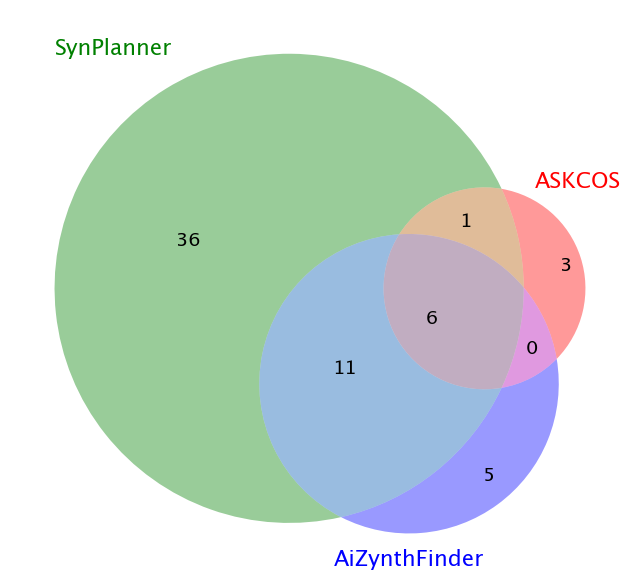

In [3]:
from cgr_clustering.visualization import plot_venn_diagram

plot_venn_diagram(syn, ask, aiz)

In [ ]:
from cgr_clustering.utils import collect_overlaps, make_keys_for_sb, merge_keys_for_sbs

df = collect_overlaps(syn, ask, aiz)
df

,Region,Count,Examples
0,Only SynPlanner,36,[c1cc(ccc1[.>-]NC(c2cccnc2N[.>-]C[.>-]c3ccncc3...
1,Only ASKCOS,3,[C1CCCC1(c2ccc(cc2)N[.>-]C([.>-]c3cccnc3[.>-]N...
2,Only AiZynthFinder,5,[C[.>-]1CCC[.>-]C[.>-]1(c2ccc(cc2)N[.>-]C(=O)c...
3,SynPlanner ∩ ASKCOS,1,[C1CCCC1(c2ccc(cc2)N[.>-]C([.>=]O)[.>-]c3c(ncc...
4,SynPlanner ∩ AiZynthFinder,11,[C1CCCC1(C#N)c2ccc(cc2)[.>-]N[.>-]C(=O)c3cccnc...
5,ASKCOS ∩ AiZynthFinder,0,[]
6,All Three,6,[c1cc(ccc1[.>-]NC(c2cccnc2[.>-]NCc3ccncc3)=O)C...


In [32]:
keys_for_sb = make_keys_for_sb(synplanner_clusters, askcos_clusters, aizynth_clusters)

row_id = 4 # In the given example SynPlanner ∩ ASKCOS results

examples = df.loc[row_id, "Examples"]
print('Number of SB-CGRs:', len(examples))

merged = merge_keys_for_sbs(examples, keys_for_sb)
merged

Number of SB-CGRs: 11


{'synplanner_keys': ['3.3',
  '2.6',
  '4.16',
  '4.14',
  '3.12',
  '3.4',
  '4.11',
  '3.2',
  '5.5',
  '3.9',
  '2.4'],
 'askcos_keys': [],
 'aizynth_keys': ['3.2',
  '2.5',
  '4.4',
  '4.3',
  '3.7',
  '3.3',
  '4.5',
  '3.1',
  '5.2',
  '3.5',
  '2.3']}

In [36]:
from synplan.chem.reaction_routes.visualisation import cgr_display
from IPython.display import display, SVG

for tool_key, val_sb_cgrs in merged.items():
    if len(val_sb_cgrs) != 0:
        print(tool_key)
        for i in val_sb_cgrs:
            print(i)
            if tool_key == 'aizynth_keys':
                w = aizynth_clusters[i]['sb_cgr']
            if tool_key == 'synplanner_keys':
                w = synplanner_clusters[i]['sb_cgr']
            if tool_key == 'askcos_keys':
                w = askcos_clusters[i]['sb_cgr']
            w.clean2d()
            display(SVG(cgr_display(w)))


synplanner_keys
3.3


2.6


4.16


4.14


3.12


3.4


4.11


3.2


5.5


3.9


2.4


aizynth_keys
3.2


2.5


4.4


4.3


3.7


3.3


4.5


3.1


5.2


3.5


2.3


### Strategic bond number histogram

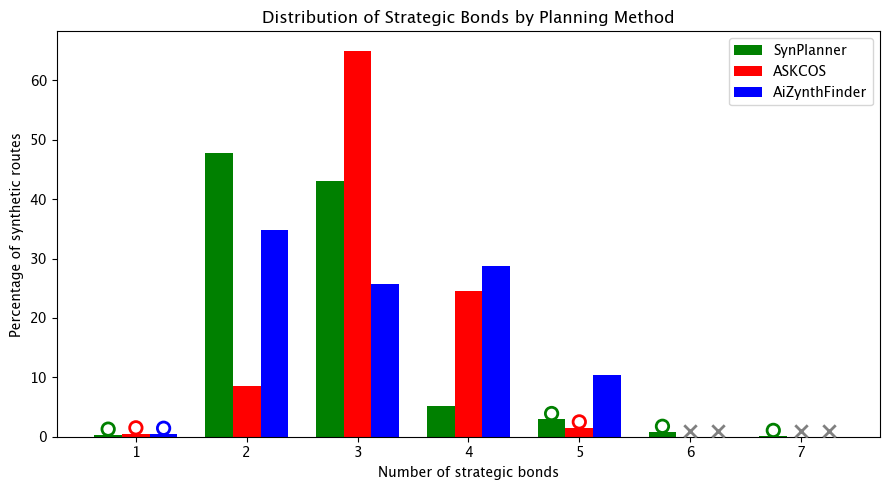

In [37]:
from cgr_clustering.utils import compute_group_percentages
from cgr_clustering.visualization import plot_sb_histogram

synplanner_perc = compute_group_percentages(synplanner_clusters)
askcos_perc =  compute_group_percentages(askcos_clusters)
aizynth_perc = compute_group_percentages(aizynth_clusters)

plot_sb_histogram(synplanner_perc, askcos_perc, aizynth_perc)